# EDA
Quick exploratory data analysis for SF Curb Ramps Data


In [21]:
import pandas as pd
from IPython.core.display import HTML
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# missing values
from cr_utils import check_missing_data,plot_histogram


<a id="top">

## Data: San Francisco's Curb Ramps (city infrastructure) 

Curb ramp locations and attribute data. These data come from the Curb Ramp Information System (CRIS). Please be advised – CRIS is a planning tool only. There is no guarantee of attribute accuracy. Also, while the data syncs nightly the underlying system only updates about once a quarter.
<a/>


In [5]:
attr_descriptions = 'values'
HTML(f'''
<div>
    <div>
        <iframe title="Curb Ramps" width="1200" height="808" src="https://data.sfgov.org/w/ch9w-7kih" frameborder="0" tabindex="0" scrolling="no"></iframe>
    </div>
</div>
'''
)

In [6]:
ramps_path = './input/archive/DPW_DataDictionary-curb-ramps.xlsx'

In [7]:
attrs_sheet = pd.read_excel(ramps_path, header=None, names=['Empty', 'Field Name', 'Data Type', 'Definition', 'Notes'])
attrs_sheet = attrs_sheet[5:][['Field Name', 'Definition', 'Data Type']]
attrs_sheet

,Field Name,Definition,Data Type
5,LocationDescription,"Name of intersection, cross streets",Text
6,locID,Primary key composed of CNN+CurbReturnLoc+Posi...,Text
7,invenID,Legacy primary key for curb ramp locations,Number
8,CNN,Intersection CNN of this curb ramp,Number
9,curbReturnLoc,"Direction of the curb return (NW, N, NE, E, SE...",Text
10,positionOnReturn,"Position of the curb ramp on the return (Left,...",Text
11,conditionScore,Condition score\nThe condition scores are as f...,Number
12,detectableSurf,Does the ramp have a detectable surface? 1= co...,Number
13,vitalFacilities,Is the path of travel critical for citizen acc...,Number
14,heavyTraffic,Is a curb ramp needed to preserve the path of ...,Number


# Load the data

In [8]:
# load the data
curb_ramps = pd.read_csv('./input/archive/curb-ramps.csv')
print(curb_ramps.shape)
curb_ramps.head()



(49768, 40)


,locID,CNN,xLoc,yLoc,LocationDescription,curbReturnLoc,positionOnReturn,Latitude,Longitude,LastUpdate,...,levelLandBottom,slopeRangeID,crPossible,crExist,Location,Fire Prevention Districts,Police Districts,Supervisor Districts,Zip Codes,Neighborhoods (old)
0,30021000-NW-Left,30021000,6.015421e+06,2.110671e+06,03RD ST: END intersection,NW,Left,37.7763,-122.390025,2020-11-10T06:44:16.000,...,NaN,NaN,N04,0,"{'latitude': '37.776300131495866', 'longitude'...",14.0,3.0,9.0,310.0,20.0
1,30021000-SE-Right,30021000,6.015507e+06,2.110610e+06,03RD ST: END intersection,SE,Right,37.7763,-122.390025,2020-11-10T06:44:16.000,...,1.0,2.0,NaN,1,"{'latitude': '37.776300131495866', 'longitude'...",14.0,3.0,9.0,310.0,20.0
2,30021000-NE-Right,30021000,6.015494e+06,2.110678e+06,03RD ST: END intersection,NE,Right,37.7763,-122.390025,2020-11-10T06:44:16.000,...,NaN,NaN,N04,0,"{'latitude': '37.776300131495866', 'longitude'...",14.0,3.0,9.0,310.0,20.0
3,30021000-SE-Left,30021000,6.015497e+06,2.110595e+06,03RD ST: END intersection,SE,Left,37.7763,-122.390025,2020-11-10T06:44:16.000,...,1.0,3.0,NaN,1,"{'latitude': '37.776300131495866', 'longitude'...",14.0,3.0,9.0,310.0,20.0
4,30021000-SW-Right,30021000,6.015426e+06,2.110594e+06,03RD ST: END intersection,SW,Right,37.7763,-122.390025,2020-11-10T06:44:16.000,...,1.0,2.0,NaN,1,"{'latitude': '37.776300131495866', 'longitude'...",14.0,3.0,9.0,310.0,20.0


In [9]:
#  Drop NA Rows 

In [10]:

(nRow, nCol) = curb_ramps.shape
print((nRow, nCol))
curb_ramps_dna = curb_ramps.dropna(axis=0, how='all')
print(curb_ramps_dna.shape)

(49768, 40)
(49768, 40)


# Count Unique and Missing Values

In [11]:
# missing values
curb_ramps_info = check_missing_data(curb_ramps)

curb_ramps_info

,Unique Vals Count,Total Missing,Percentage Missing,Dupes
paintedRed,2,44134,88.68,5632
flushToCorner,2,44066,88.54,5700
probStreetMeetCR,2,43509,87.42,6257
topClearance,2,43509,87.42,6257
sideClearance,2,43509,87.42,6257
heavyTraffic,2,41454,83.29,8312
vitalFacilities,2,41034,82.45,8732
possBasementObstacle,2,35402,71.13,14364
crPossible,15,32877,66.06,16876
levelLandBottom,2,20191,40.57,29575


# Boolean Columns

In [13]:
unique_vals_count = curb_ramps_info['Unique Vals Count']
bool_cols = [col for col in curb_ramps.columns if int(unique_vals_count[col]) is 2]
# bool_cols

In [14]:

check_missing_data(curb_ramps[bool_cols])

,Unique Vals Count,Total Missing,Percentage Missing,Dupes
paintedRed,2,44134,88.68,5632
flushToCorner,2,44066,88.54,5700
probStreetMeetCR,2,43509,87.42,6257
topClearance,2,43509,87.42,6257
sideClearance,2,43509,87.42,6257
heavyTraffic,2,41454,83.29,8312
vitalFacilities,2,41034,82.45,8732
possBasementObstacle,2,35402,71.13,14364
levelLandBottom,2,20191,40.57,29575
detectableSurf,2,19683,39.55,30083


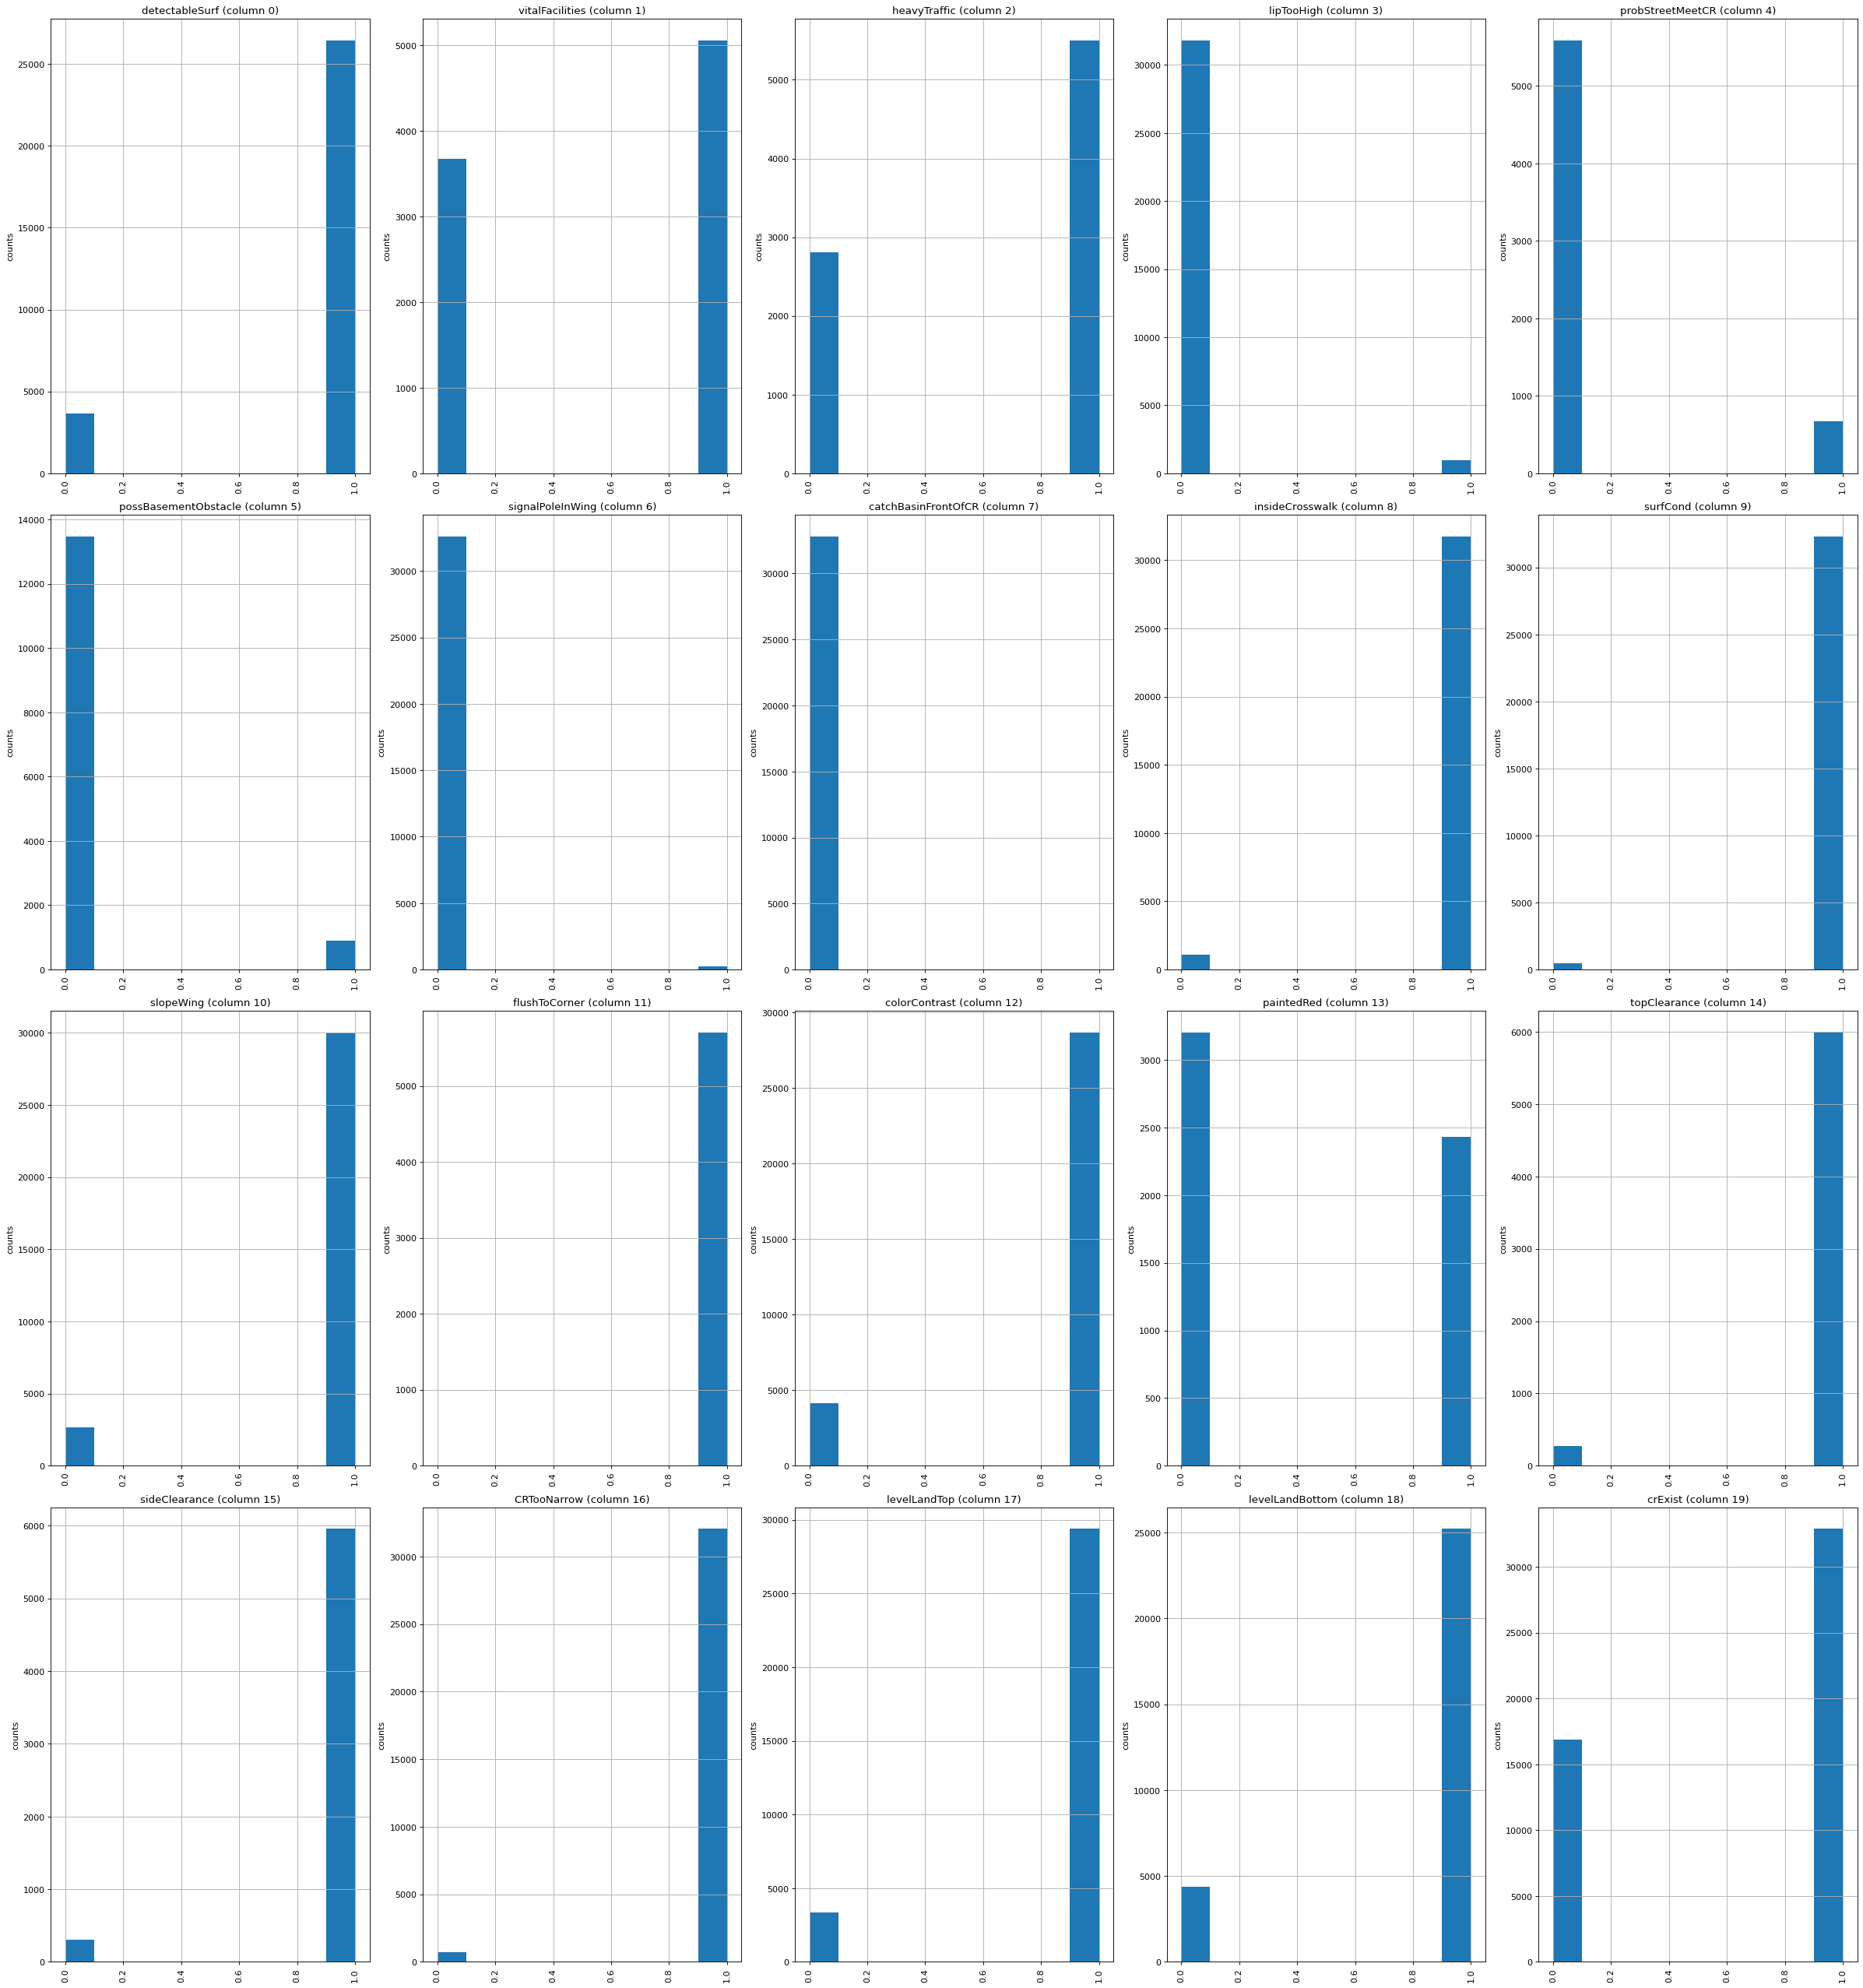

In [24]:
# Histogram of column data
def plot_histogram(df, nHistogramShown, nHistogramPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nHistRow = int((nCol + nHistogramPerRow - 1) / nHistogramPerRow)
    plt.figure(num=None, figsize=(6*nHistogramPerRow, 8*nHistRow), dpi=80, facecolor='w', edgecolor='k')
    for i in range(min(nCol, nHistogramShown)):
        plt.subplot(nHistRow, nHistogramPerRow, i+1)
        df.iloc[:,i].hist()
        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()

plot_histogram(curb_ramps[bool_cols], 20, 5)

# Numerical columns, Non Boolean

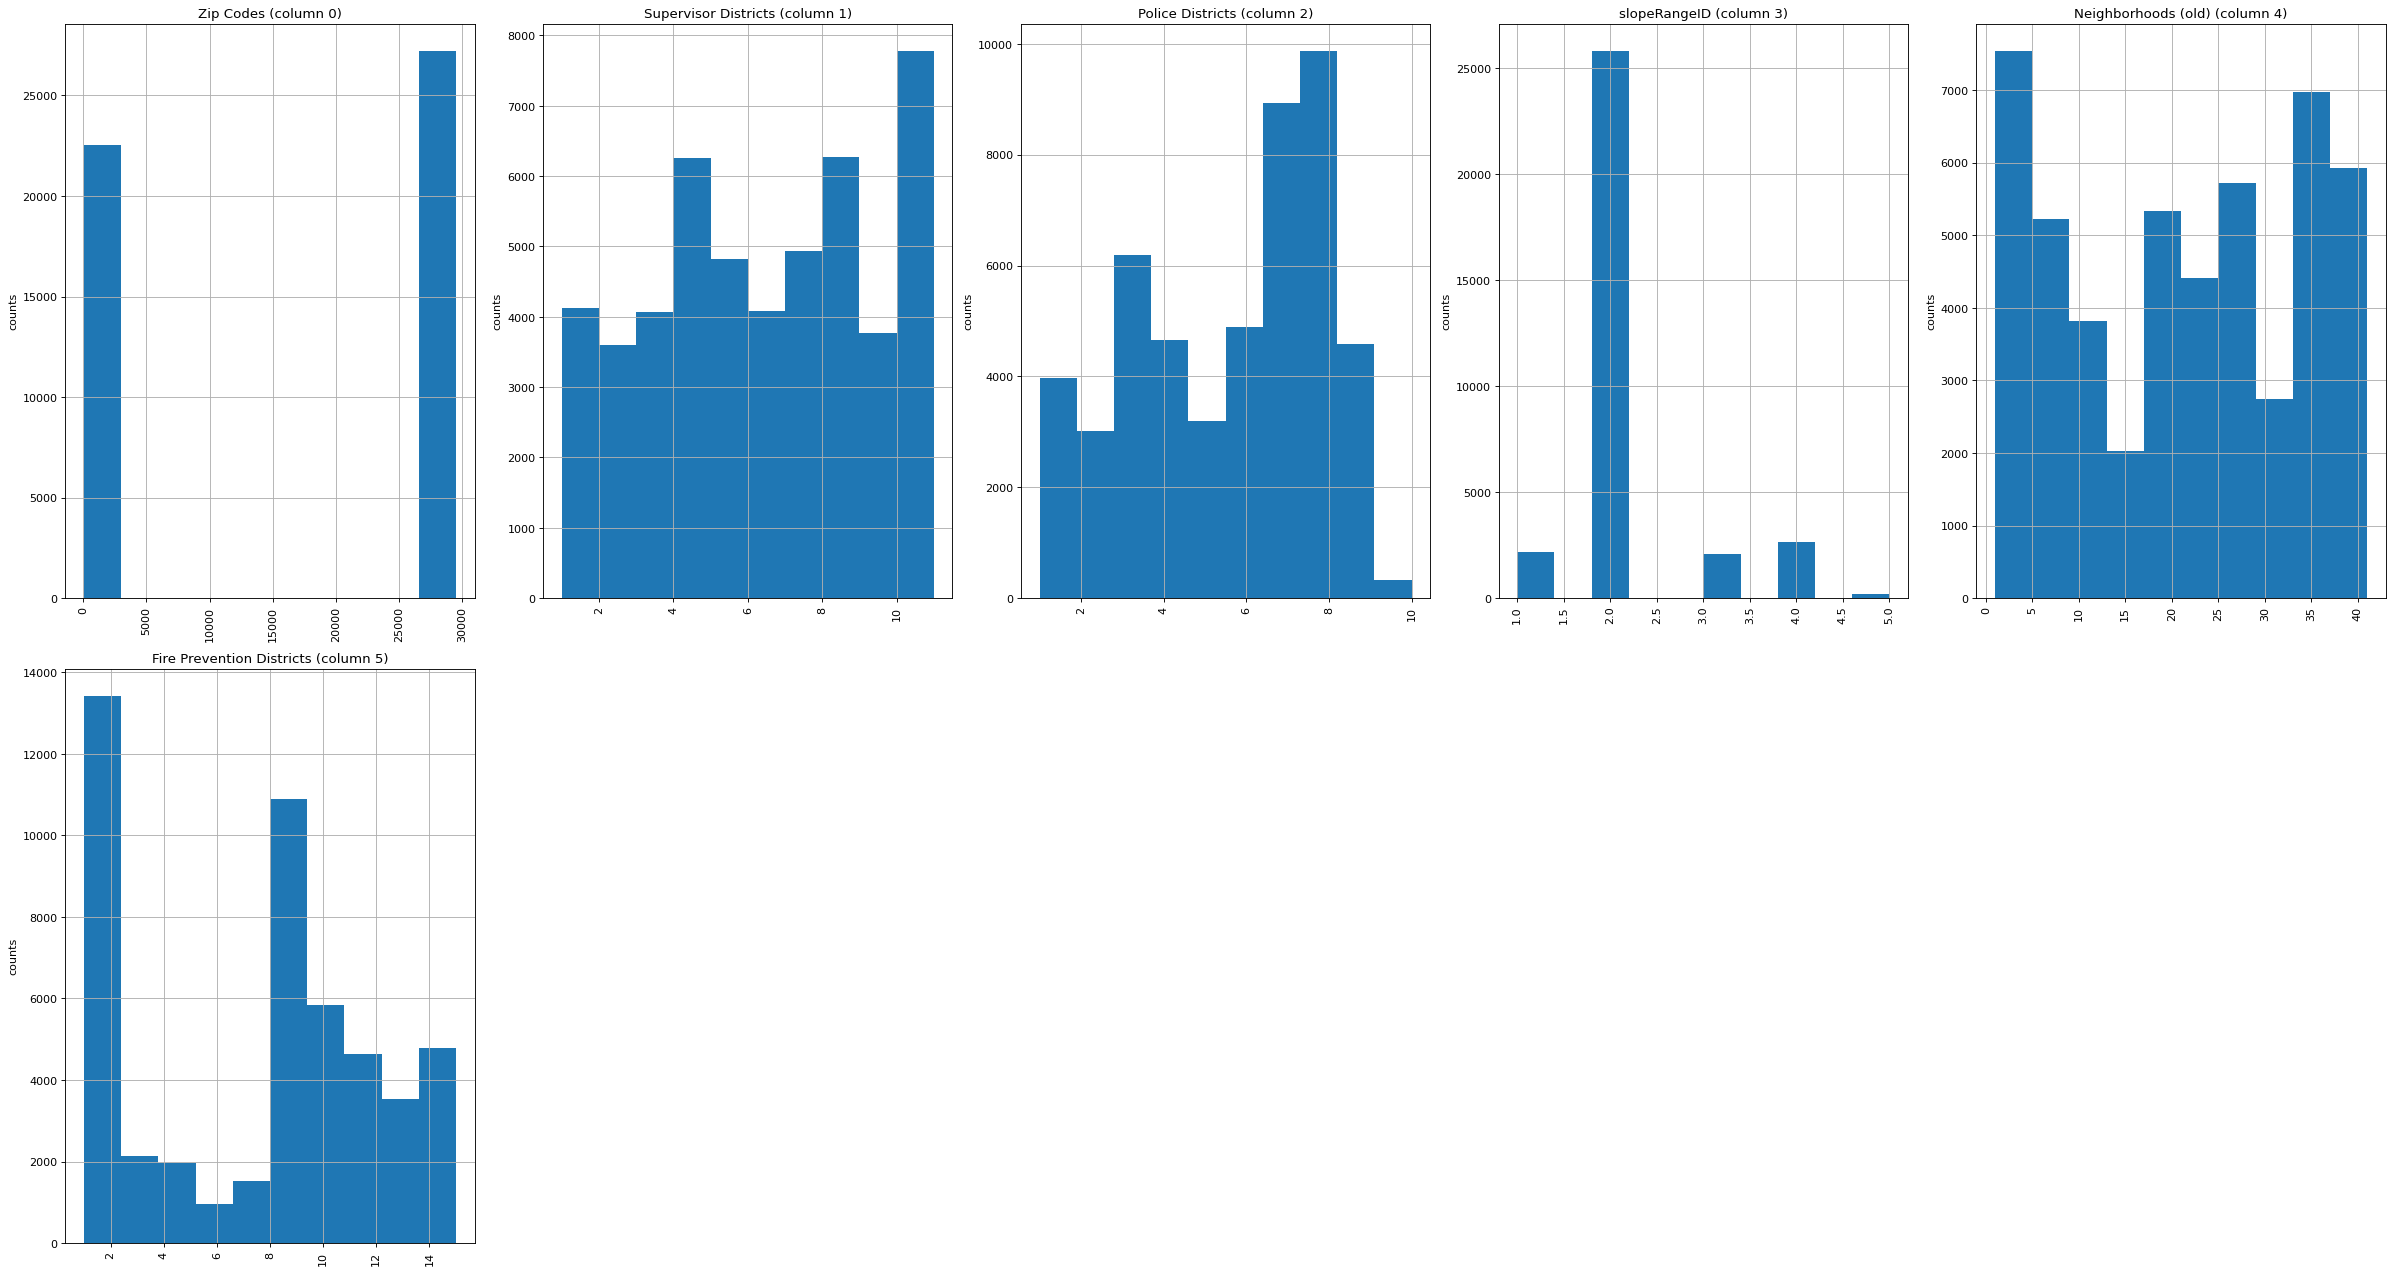

In [25]:

cr_description = curb_ramps.describe()
numerical_cols = list(set(cr_description.columns) - set(bool_cols))
numerical_data_info = cr_description[numerical_cols]
description_df = pd.DataFrame([pd.Series(numerical_data_info[row]) for row in numerical_data_info])
plot_histogram(curb_ramps[numerical_cols], 20, 5)
# description_df

In [19]:
# numerical columns
missing_numerical = check_missing_data(curb_ramps[numerical_cols])
pd.concat([missing_numerical, description_df], axis=1)

,Unique Vals Count,Total Missing,Percentage Missing,Dupes,count,mean,std,min,25%,50%,75%,max
slopeRangeID,5,16891,33.94,32872,32877.0,2.174803e+00,6.855807e-01,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
Police Districts,10,115,0.23,49643,49653.0,5.611262e+00,2.509583e+00,1.000000e+00,3.000000e+00,6.000000e+00,8.000000e+00,1.000000e+01
Fire Prevention Districts,15,79,0.16,49674,49689.0,7.511159e+00,4.554165e+00,1.000000e+00,2.000000e+00,9.000000e+00,1.100000e+01,1.500000e+01
Neighborhoods (old),40,77,0.15,49651,49691.0,2.069656e+01,1.295665e+01,1.000000e+00,8.000000e+00,2.200000e+01,3.400000e+01,4.100000e+01
Supervisor Districts,11,50,0.10,49707,49718.0,5.979565e+00,3.004804e+00,1.000000e+00,4.000000e+00,6.000000e+00,8.000000e+00,1.100000e+01
Zip Codes,28,14,0.03,49726,49754.0,1.590690e+04,1.439036e+04,5.400000e+01,5.900000e+01,2.885300e+04,2.886100e+04,2.949200e+04
InvenID,49762,6,0.01,0,49762.0,2.641680e+04,1.518227e+04,4.000000e+00,1.329650e+04,2.647950e+04,3.953175e+04,5.297300e+04
Longitude,7458,4,0.01,42306,49764.0,-1.224371e+02,3.211731e-02,-1.225130e+02,-1.224613e+02,-1.224325e+02,-1.224110e+02,-1.223704e+02
Latitude,7458,4,0.01,42306,49764.0,3.775685e+01,2.653882e-02,3.770736e+01,3.773442e+01,3.775688e+01,3.777944e+01,3.780897e+01
yLoc,49603,0,0.00,165,49768.0,2.103845e+06,9.643228e+03,2.085874e+06,2.095679e+06,2.103855e+06,2.112118e+06,2.122786e+06


# Categorical Columns

Categorical: {'LastUpdate', 'locID', 'curbReturnLoc', 'crPossible', 'Location', 'LocationDescription', 'positionOnReturn'}


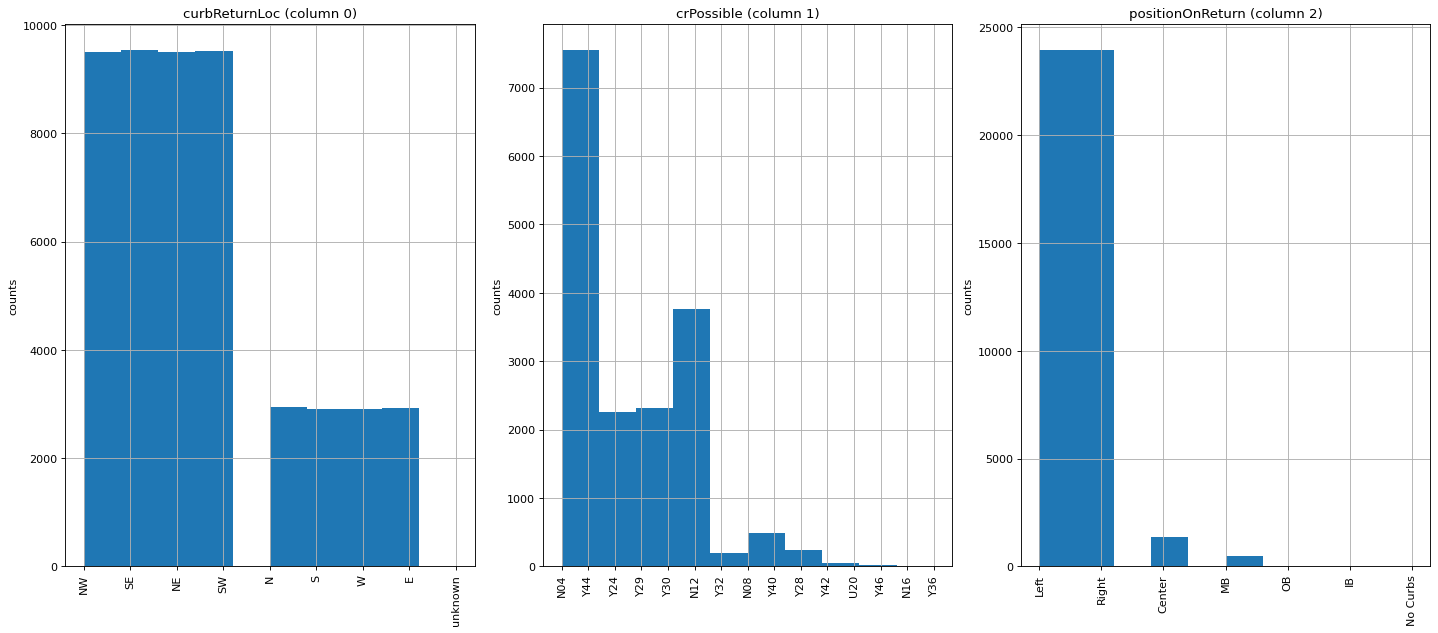

In [28]:
# CategoricalColumns
# https://vega.github.io/vega-lite/examples/interactive_layered_crossfilter.html
categorical_columns = set(curb_ramps.columns) - set(numerical_cols).union(bool_cols)
print('Categorical:', categorical_columns)
plot_histogram(curb_ramps[list(categorical_columns)],20, 5)

In [25]:
val_counts = [curb_ramps[col].value_counts() for col in list(categorical_columns)]
val_counts
# categorical_qts = [(vcount , vcount[0], len(vcount)) for vcount in val_counts]
# categorical_qts

[LastUpdate
 2020-11-10T06:44:16.000    49768
 Name: count, dtype: int64,
 crPossible
 Y44    4937
 N12    3769
 N04    2616
 Y24    2250
 Y30    1426
 Y29     892
 N08     320
 Y28     244
 Y32     189
 Y40     161
 Y42      43
 Y46      24
 N16      11
 U20       8
 Y36       1
 Name: count, dtype: int64,
 locID
 21988000-SE-Left     2
 30021000-NW-Left     1
 23621000-NE-Right    1
 24369000-NW-Left     1
 24002000-SE-Right    1
                     ..
 27910000-NW-Left     1
 22528000-NE-Right    1
 27797000-SW-Left     1
 24079000-NE-Left     1
 26667000-SW-Left     1
 Name: count, Length: 49767, dtype: int64,
 LocationDescription
 BUCKINGHAM WAY: 19TH AVE to WINSTON DR (1 - 399)                                                    29
 JUNIPERO SERRA BLVD: PORTOLA DR \ SAINT FRANCIS BLVD \ SLOAT BLVD \ WEST PORTAL AVE intersection    29
 GEARY BLVD: WEBSTER ST intersection                                                                 25
 HOLLOWAY AVE: JUNIPERO SERRA BLVD intersect

In [17]:

check_missing_data(curb_ramps[list(categorical_columns)])


,Unique Vals Count,Total Missing,Percentage Missing,Dupes
crPossible,15,32877,66.06,16876
Location,7458,4,0.01,42306
positionOnReturn,7,4,0.01,49757
locID,49767,0,0.00,1
LocationDescription,7284,0,0.00,42484
curbReturnLoc,9,0,0.00,49759
LastUpdate,1,0,0.00,49767


In [ ]:
# SELECT :id WHERE (within_polygon(snap_to_grid(location,0.00024414),'POLYGON((-122.40710341724284 37.77964420677678, -122.40721142498128 37.77964420677678, -122.40721142498128 37.77972956164261, -122.40710341724284 37.77972956164261, -122.40710341724284 37.77964420677678))') OR intersects(snap_to_grid(location,0.00024414),'POLYGON((-122.40710341724284 37.77964420677678, -122.40721142498128 37.77964420677678, -122.40721142498128 37.77972956164261, -122.40710341724284 37.77972956164261, -122.40710341724284 37.77964420677678))'))
